# Introduction

For this project we are creating a predictive model that will determine when a customer is likely to end their service. In order to do this, we will create a model that classifies users as having a plan that was cancelled compared to long-standing users and will predict based on their data when a user is likely to cancel. We will start by preparing and cleaning the data for an exploratory data analysis. Data analysis will show corrolation between different features and target and we will able to decide how we will train our model.

In [31]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from scipy.stats import randint, uniform

from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_curve, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, average_precision_score, accuracy_score
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

# Data Preprocessing

### Loading Data

In [32]:
try:
    contract=pd.read_csv('/datasets/final_provider/contract.csv')
    personal=pd.read_csv('/datasets/final_provider/personal.csv')
    internet=pd.read_csv('/datasets/final_provider/internet.csv')
    phone=pd.read_csv('/datasets/final_provider/phone.csv')
    print('Dataframes loaded successfully!')
except: 
    print('something went wrong!')

Dataframes loaded successfully!


In [33]:
dfs = {
    'contract': contract,
    'personal': personal, 
    'internet': internet,
    'phone': phone
}

In [34]:
#displaying 5 row of each table and dataframe info
for name, df in dfs.items():
        print(f"\n{'='*20} DataFrame: {name} {'='*20}")
        
        print("\n--- First 5 Rows ---")
        
        print(df.head()) 
        
        print("\n--- DataFrame Info ---")
       
        df.info()
        print("-" * 50)


==================== DataFrame: contract ====================

--- First 5 Rows ---
   customerID   BeginDate              EndDate            Type  \
0  7590-VHVEG  2020-01-01                   No  Month-to-month   
1  5575-GNVDE  2017-04-01                   No        One year   
2  3668-QPYBK  2019-10-01  2019-12-01 00:00:00  Month-to-month   
3  7795-CFOCW  2016-05-01                   No        One year   
4  9237-HQITU  2019-09-01  2019-11-01 00:00:00  Month-to-month   

  PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges  
0              Yes           Electronic check           29.85        29.85  
1               No               Mailed check           56.95       1889.5  
2              Yes               Mailed check           53.85       108.15  
3               No  Bank transfer (automatic)           42.30      1840.75  
4              Yes           Electronic check           70.70       151.65  

--- DataFrame Info ---
<class 'pandas.core.frame.DataFr

### Fixing Column Names
we can see that column  names are not all in upper case nor lower case. we need to fix this by making all columns lower case in order to avoid any confusion.

In [35]:
#function to make all column names in all dataframes lower case
def lowercase_columns(df):
      df.rename(columns=str.lower, inplace=True)
for names, df in dfs.items():
    lowercase_columns(df)
    print(f"{names} columns:", df.columns.tolist())

contract columns: ['customerid', 'begindate', 'enddate', 'type', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges']
personal columns: ['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents']
internet columns: ['customerid', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies']
phone columns: ['customerid', 'multiplelines']


### checking for Duplicates

In [36]:
#checking for duplicates in all dataframes
for names, df in dfs.items():
   duplicated_rows=df.duplicated().sum()
   print (f"{names} duplicated rows:",  duplicated_rows)

contract duplicated rows: 0
personal duplicated rows: 0
internet duplicated rows: 0
phone duplicated rows: 0


### Fixing Data Types

We  see that the datatype of 'begindate' and 'enddate' columns is not datetime type so we need to fix this. Also with 'enddate' column before switching the data type we will switch 'No' with the date: "2020-02-01", because, in the description of the dataset, it was mentioned that data is valid as of February 2020.

In [37]:
#'begindate' to datetime type
contract['begindate']=pd.to_datetime(contract['begindate'],format='%Y/%m/%d')
contract.info() #to test

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerid        7043 non-null   object        
 1   begindate         7043 non-null   datetime64[ns]
 2   enddate           7043 non-null   object        
 3   type              7043 non-null   object        
 4   paperlessbilling  7043 non-null   object        
 5   paymentmethod     7043 non-null   object        
 6   monthlycharges    7043 non-null   float64       
 7   totalcharges      7043 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 440.3+ KB


In [38]:
#replacing No's to '2020-02-01' in 'enddate'
contract['enddate'] = contract['enddate'].replace('No', '2020-02-01')
#'enddate' column to datetime type
contract['enddate'] = pd.to_datetime(contract['enddate'])
contract.info() #to test

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerid        7043 non-null   object        
 1   begindate         7043 non-null   datetime64[ns]
 2   enddate           7043 non-null   datetime64[ns]
 3   type              7043 non-null   object        
 4   paperlessbilling  7043 non-null   object        
 5   paymentmethod     7043 non-null   object        
 6   monthlycharges    7043 non-null   float64       
 7   totalcharges      7043 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(5)
memory usage: 440.3+ KB


'total_charges' column contains numbers, But its data type Is object. Most probably, it contains some strange values or it was loaded as an object type just by mistake. let's figure out this.

In [39]:
(contract['totalcharges']==' ').sum()

11

In [40]:
contract[contract['totalcharges']==' ']

,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges
488,4472-LVYGI,2020-02-01,2020-02-01,Two year,Yes,Bank transfer (automatic),52.55,
753,3115-CZMZD,2020-02-01,2020-02-01,Two year,No,Mailed check,20.25,
936,5709-LVOEQ,2020-02-01,2020-02-01,Two year,No,Mailed check,80.85,
1082,4367-NUYAO,2020-02-01,2020-02-01,Two year,No,Mailed check,25.75,
1340,1371-DWPAZ,2020-02-01,2020-02-01,Two year,No,Credit card (automatic),56.05,
3331,7644-OMVMY,2020-02-01,2020-02-01,Two year,No,Mailed check,19.85,
3826,3213-VVOLG,2020-02-01,2020-02-01,Two year,No,Mailed check,25.35,
4380,2520-SGTTA,2020-02-01,2020-02-01,Two year,No,Mailed check,20.00,
5218,2923-ARZLG,2020-02-01,2020-02-01,One year,Yes,Mailed check,19.70,
6670,4075-WKNIU,2020-02-01,2020-02-01,Two year,No,Mailed check,73.35,


so looks that we have 11 empty strings for the totalcharges in contract. Looking at the rows, where we have the empty strings, we see that all customers just started subscribtion (they are fresh customers ). We can replace these empty stings with the corresponding 'monthlycharge', because for fresh customers totalcharges = monthlycharges.

In [41]:
contract['totalcharges'] = np.where(
    contract['totalcharges'] == ' ',
    contract['monthlycharges'],
    contract['totalcharges']
)
(contract['totalcharges']==' ').sum()

0

In [42]:
#now we are changing the datatype of total charges to float
contract['totalcharges'] = contract['totalcharges'].astype(float)

In [43]:
#checking values of type and paymentmethod columns:
print(contract['type'].unique())
print(contract['paymentmethod'].unique())

['Month-to-month' 'One year' 'Two year']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [44]:
#checking values of the column internetservice
internet['internetservice'].unique()

array(['DSL', 'Fiber optic'], dtype=object)

### Merging dataframes together

Before we merge the dataframes we need to deal with the 2 dataframes phone and internet they have less than 7043 columns so we will have NaN in some columns when merging. .......What should we do with these missing values?.............
We cant just delete these values  or consider it as missing values because we will lose many customers information leading to inaccurate results. We will replace NaN values with 'No' because these customers are not available in the internet and phone dataframes did not have internet or phone line but exicted. They can be either still using customers that dont have internet or phone services or churned customers that never had the service. 

In [45]:
df_final = contract.merge(internet, on="customerid", how="left")
df_final = df_final.merge(personal, on="customerid", how="left")
df_final = df_final.merge(phone, on="customerid", how="left")
df_final=df_final.fillna('No') # replacing missing data with No (why is explained above)
df_final.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerid        7043 non-null   object        
 1   begindate         7043 non-null   datetime64[ns]
 2   enddate           7043 non-null   datetime64[ns]
 3   type              7043 non-null   object        
 4   paperlessbilling  7043 non-null   object        
 5   paymentmethod     7043 non-null   object        
 6   monthlycharges    7043 non-null   float64       
 7   totalcharges      7043 non-null   float64       
 8   internetservice   7043 non-null   object        
 9   onlinesecurity    7043 non-null   object        
 10  onlinebackup      7043 non-null   object        
 11  deviceprotection  7043 non-null   object        
 12  techsupport       7043 non-null   object        
 13  streamingtv       7043 non-null   object        
 14  streamingmovies   7043 n

### Mapping 'Yes' and 'No' to '0' and '1'

In [46]:
bool_cols = ['paperlessbilling', 'partner', 'dependents', 'onlinesecurity', 'onlinebackup', 
             'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'multiplelines']

# convert to boolean

for columns in bool_cols:
    df_final[columns] = df_final[columns].map({'Yes' : 1 ,'No' : 0})

# convert gender to boolean
df_final['gender'] = df_final['gender'].map({'Male' : 1 ,'Female' : 0})

df_final.sample(10)

,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,gender,seniorcitizen,partner,dependents,multiplelines
1265,1004-NOZNR,2015-06-01,2020-02-01,One year,0,Credit card (automatic),94.80,5264.30,Fiber optic,1,0,0,0,1,1,1,1,0,1,0
6663,0674-EYYZV,2020-01-01,2020-02-01,Month-to-month,1,Electronic check,54.65,54.65,DSL,0,0,0,0,1,0,0,0,0,0,0
4597,3440-JPSCL,2019-05-01,2019-11-01,Month-to-month,1,Mailed check,99.95,547.65,Fiber optic,0,0,1,1,1,1,0,0,0,0,0
5298,5647-FXOTP,2015-02-01,2020-02-01,Month-to-month,1,Electronic check,105.90,6401.25,Fiber optic,0,1,1,0,1,1,0,1,1,0,1
2096,0761-AETCS,2019-11-01,2019-12-01,Month-to-month,0,Electronic check,19.30,19.30,No,0,0,0,0,0,0,0,0,0,0,0
79,3887-PBQAO,2016-05-01,2020-02-01,One year,1,Credit card (automatic),25.90,1216.60,No,0,0,0,0,0,0,0,0,1,1,1
6988,1684-FLBGS,2018-03-01,2020-02-01,Month-to-month,1,Credit card (automatic),69.50,1652.10,DSL,0,1,0,1,1,0,0,0,1,1,1
857,2207-NHRJK,2019-11-01,2019-12-01,Month-to-month,0,Electronic check,50.80,50.80,DSL,0,1,0,0,0,0,1,0,0,0,0
4341,3754-DXMRT,2019-09-01,2019-11-01,Month-to-month,1,Electronic check,44.15,92.65,DSL,0,0,0,0,0,0,1,1,0,0,0
2800,0519-DRGTI,2018-06-01,2020-02-01,Month-to-month,0,Mailed check,20.35,442.60,No,0,0,0,0,0,0,0,0,1,1,0


In [47]:
df_final['internetservice'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

### Adding New Features

In [48]:
#adding a column to show if service ended or not  
df_final['stillusing']=np.where(df_final['enddate']== '2020-02-01', 1, 0)

df_final.sample(20)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerid        7043 non-null   object        
 1   begindate         7043 non-null   datetime64[ns]
 2   enddate           7043 non-null   datetime64[ns]
 3   type              7043 non-null   object        
 4   paperlessbilling  7043 non-null   int64         
 5   paymentmethod     7043 non-null   object        
 6   monthlycharges    7043 non-null   float64       
 7   totalcharges      7043 non-null   float64       
 8   internetservice   7043 non-null   object        
 9   onlinesecurity    7043 non-null   int64         
 10  onlinebackup      7043 non-null   int64         
 11  deviceprotection  7043 non-null   int64         
 12  techsupport       7043 non-null   int64         
 13  streamingtv       7043 non-null   int64         
 14  streamingmovies   7043 n

In [49]:
#add a new column that shows time of subscription
df_final['periodofuse']=((df_final['enddate']-df_final['begindate']).dt.days/30).astype(int)
df_final.sample(10)

,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,gender,seniorcitizen,partner,dependents,multiplelines,stillusing,periodofuse
3159,5150-ITWWB,2019-11-01,2020-02-01,Month-to-month,1,Electronic check,94.85,335.75,Fiber optic,0,...,0,1,1,1,1,0,0,1,1,3
3649,0174-QRVVY,2014-03-01,2020-02-01,Two year,0,Credit card (automatic),25.35,1847.55,No,0,...,0,0,0,1,0,1,1,1,1,72
880,9851-KIELU,2019-03-01,2020-01-01,Month-to-month,1,Electronic check,110.10,1043.30,Fiber optic,1,...,1,1,1,1,0,0,0,0,0,10
1637,4999-IEZLT,2014-08-01,2020-02-01,One year,0,Credit card (automatic),29.45,1983.15,DSL,0,...,1,0,0,1,0,0,0,0,1,67
3651,2900-PHPLN,2014-04-01,2020-02-01,Two year,1,Credit card (automatic),19.55,1462.05,No,0,...,0,0,0,0,1,1,0,0,1,71
1829,3030-YDNRM,2019-06-01,2020-02-01,Month-to-month,1,Electronic check,74.85,572.45,Fiber optic,0,...,0,0,0,1,0,0,0,1,1,8
5835,4641-FROLU,2017-08-01,2020-02-01,Two year,0,Mailed check,19.30,602.90,No,0,...,0,0,0,0,0,1,1,0,1,30
6248,6549-BTYPG,2015-02-01,2020-02-01,Two year,0,Credit card (automatic),60.80,3603.45,DSL,0,...,1,1,1,0,0,1,0,0,1,60
2064,7061-OVMIM,2017-08-01,2020-02-01,One year,0,Bank transfer (automatic),19.55,608.50,No,0,...,0,0,0,0,0,1,1,0,1,30
3201,4717-GHADL,2015-12-01,2020-02-01,Two year,1,Mailed check,79.60,4024.20,DSL,0,...,1,1,1,0,0,0,0,1,1,50


In [50]:
print(df_final['totalcharges'].dtype) #for testing

float64


# Exploratory Data Analysis

We will visualize the data. Check across specific metrics that are not clear and can be determined after preprocessing. Create histogram, box plot, and correlation matrix. Check for outliers
Determine which of our features are likely to have a connection to our target and take a closer look at those.
If encoding is deemed useful, we could check our class imbalance
If our classes are sufficiently imbalanced, we can find an ideal threshold when building our models to achieve a higher accuracy

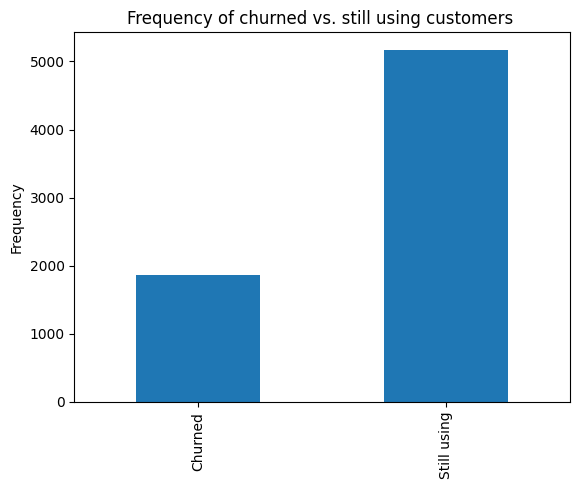

In [51]:
customers=pd.Series(df_final['stillusing']).value_counts().sort_index()
customers.index=['Churned','Still using']

customers.plot(kind='bar')
plt.ylabel('Frequency')
plt.title('Frequency of churned vs. still using customers ')
plt.show()

looking at this graph we can see that customers that are still using service are 3 folds greater than those who churned. keeping in mind that our target is not a number, we can say that this is an unbalances classification task.

Let's visualize the data and dig deeper to understand the relation between features and target 

### Distribution plots of monthly charges, total charges and lifetime of being a customer

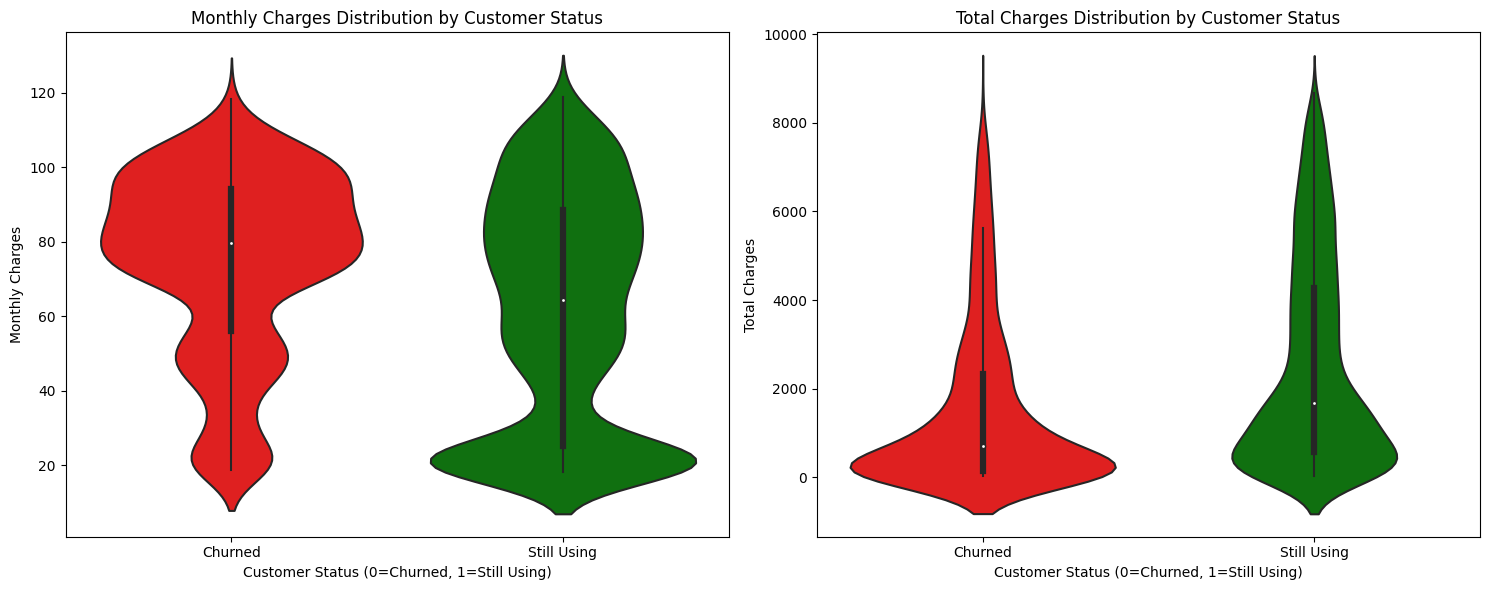

In [52]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# First subplot - Monthly Charges
sns.violinplot(data=df_final, x='stillusing', y='monthlycharges',
               palette={0: 'red', 1: 'green'}, ax=axes[0])
axes[0].set_title('Monthly Charges Distribution by Customer Status')
axes[0].set_xlabel('Customer Status (0=Churned, 1=Still Using)')
axes[0].set_ylabel('Monthly Charges')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Churned', 'Still Using'])

# Second subplot - Total Charges
sns.violinplot(data=df_final, x='stillusing', y='totalcharges',
               palette={0: 'red', 1: 'green'}, ax=axes[1])
axes[1].set_title('Total Charges Distribution by Customer Status')
axes[1].set_xlabel('Customer Status (0=Churned, 1=Still Using)')
axes[1].set_ylabel('Total Charges')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Churned', 'Still Using'])

plt.tight_layout()

The above distributions have shown that monthly charges of "still_using" customers are at the lower side, so with most of the customers at a lower monthly charge tend to stay. While monthly charges of "churned" customers distribution violin plot shows that most of the churned customers are in the higher monthly charge range.

Regarding the distribution of total charges, both "still_using" and "churned" customers have a similar distribution, where more customers are located at a lower total charge range. This could be related to the life time of customers, where total charges are lower when a customer is fresh a customer and looks like fresh customers tend to leave more.  

### The relation between the count of customers that stay or leave and the number of dependants

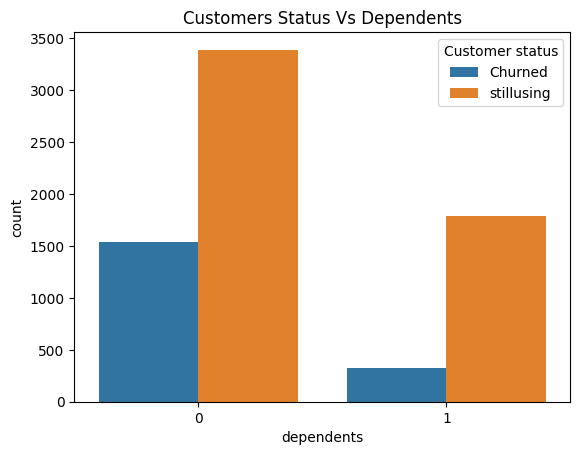

In [53]:
df_final['stillusing'].map({0: 'Churned', 1: 'Still Using'})
sns.countplot(x='dependents', hue='stillusing', data=df_final)
plt.title('Customers Status Vs Dependents')
plt.legend(title='Customer status', labels=['Churned', 'stillusing'])
plt.show()


looking at the countplot above we can notice that the number of customers that churned is higher when they dont have dependents. Looks like it is not worth the money when there is only one individual in the house uses the service.

### The internet status of churned and still using customers

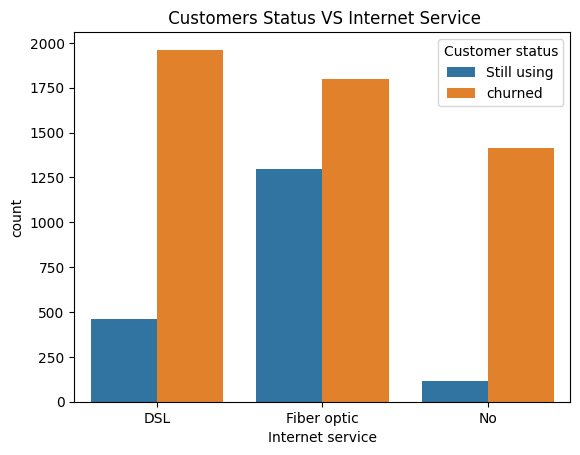

In [54]:


sns.countplot(x='internetservice', hue='stillusing', data=df_final)
plt.title(' Customers Status VS Internet Service')
plt.xlabel('Internet service')
plt.legend(title='Customer status', labels=['Still using', 'churned'])
plt.show()



In the plot above, we can see the relation between having internet or not and customer status. we can see that with internet service or without internet service churned customers ia way higher than still using customers. Meaning there is no relation between having internet service and number of churned customers.

### Number of months of subscription and the status of customers

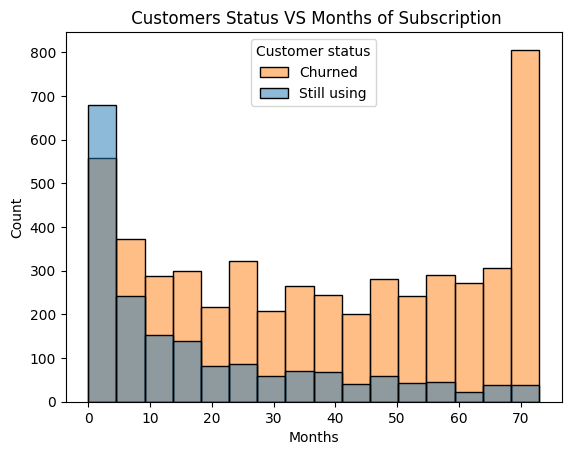

In [55]:
sns.histplot(x='periodofuse', hue='stillusing', data=df_final)
plt.title(' Customers Status VS Months of Subscription')
plt.xlabel('Months')
plt.legend(title='Customer status', labels=['Churned', 'Still using'])
plt.show()

We can see it clearly that as the number of months of service increase, the churned customers decrease. This shows that the above conclusion about fresh customers tend to leave more is right.

### Relation between the contract type and the status of customers

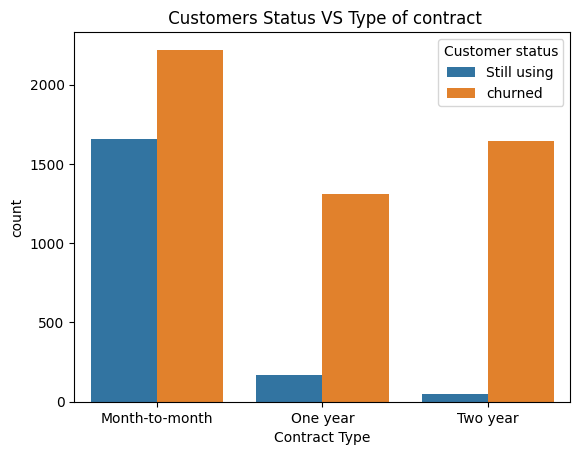

In [56]:
sns.countplot(x='type', hue='stillusing', data=df_final)
plt.title(' Customers Status VS Type of contract')
plt.xlabel('Contract Type')
plt.legend(title='Customer status', labels=['Still using', 'churned'])
plt.show()


This plot shows that the relation of the contract time and the status of the customer is highly related. The longer the contact the less teh number of churned customers. Month to month customers tend to leave. It is better if we can encourage customers to sign 2 years contract!

### The correlation of numerical columns

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5]),
 [Text(0, 0.5, 'paperlessbilling'),
  Text(0, 1.5, 'monthlycharges'),
  Text(0, 2.5, 'totalcharges'),
  Text(0, 3.5, 'onlinesecurity'),
  Text(0, 4.5, 'onlinebackup'),
  Text(0, 5.5, 'deviceprotection'),
  Text(0, 6.5, 'techsupport'),
  Text(0, 7.5, 'streamingtv'),
  Text(0, 8.5, 'streamingmovies'),
  Text(0, 9.5, 'gender'),
  Text(0, 10.5, 'seniorcitizen'),
  Text(0, 11.5, 'partner'),
  Text(0, 12.5, 'dependents'),
  Text(0, 13.5, 'multiplelines'),
  Text(0, 14.5, 'stillusing'),
  Text(0, 15.5, 'periodofuse')])

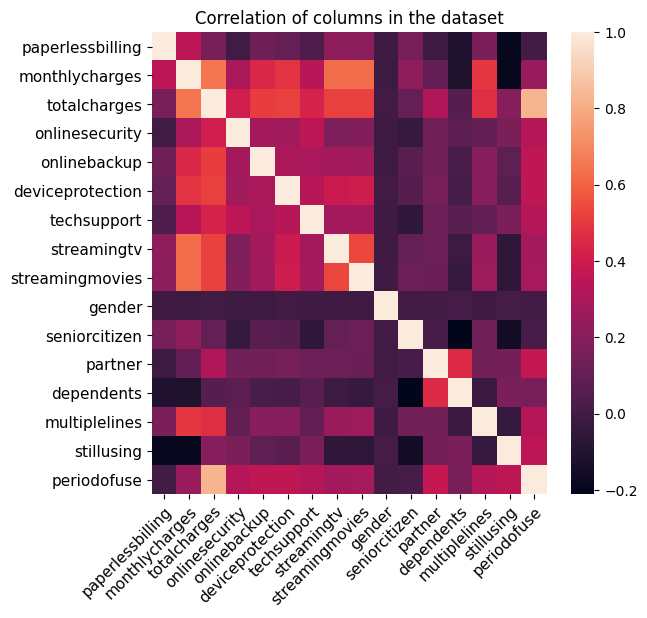

In [57]:
# correlation of columns
matrix = df_final.corr()

# plot of correlations
plt.figure(figsize=(14, 6))
plt.subplot(121)
sns.heatmap(matrix)
plt.title("Correlation of columns in the dataset")
plt.xticks(rotation=45, ha="right", rotation_mode="anchor", fontsize=11)
plt.yticks(fontsize=11)

From this heat map we can generally say that there is no high correlation between columns.There is a high correlation between period of use and total charges. It really make sense because the more the customer stay the more they pay. other than that we can see a correlation between monthly payments and some services like streaming movie and streaming TV. the more services u get the higher is your monthly payments.

### Conclusion

looking at the data and after analyzing the plots we performed. we can say that it might be that customer comes to the Interconnect and they want to make sure that the services match their expectations. So they signs a month-to-month contract,then something goes wrong: either customer is not satisfied with performance per price or the performance per price of the operator is not attractive. Finally, they decides to quit in the early months of the contract. We where able to see how price and number of dependants affected the number of churned customers so money is a big issue for customers and they want the services to be worth the money.

# Preparing the Data for Modeling in ML

Before starting data modeling , we will create a function for upsampeling the target. As we mentioned earilier it is an unbalanced classification project. Also, we will prepare data according to each algorithm we are using. One-hot encoding will be used for logistic regression, label encoding for RandomForest, and data without encoding will be used for LightGBM. Then we will create features and targets, split them into training and testing datasets.

In [58]:
# function to upsample data
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]
    features_upsampled = pd.concat([features_ones] + [features_zeros] * repeat)
    target_upsampled = pd.concat([target_ones] + [target_zeros] * repeat)
    # shuffle both features and target
    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=234
    )
    return features_upsampled, target_upsampled


### Target and Features 

In [59]:
features= df_final.drop(['customerid', 'begindate', 'enddate', 'stillusing'], axis=1)
target = df_final['stillusing']
features.shape, target.shape

((7043, 18), (7043,))

### Splitting Data

In [60]:

#original features
features_train, features_valid, target_train, target_valid = train_test_split(features, target, test_size=0.25, random_state=1234)
features_train, features_test, target_train, target_test=train_test_split(features, target, test_size=0.20, random_state=1234)

#upsampled data 
features_upsampled, target_upsampled = upsample(
    features_train, target_train, 2)
features_upsampled_train, features_upsampled_valid, target_upsampled_train, target_upsampled_valid = train_test_split(features_upsampled, target_upsampled, test_size=0.25, random_state=1234 )
features_upsampled_train, features_upsampled_test, target_upsampled_train, target_upsampled_test  = train_test_split(features_upsampled, target_upsampled, test_size=0.20, random_state=1234 )


print("Training set:", features_train.shape, target_train.shape)
print("Validation set:", features_valid.shape, target_valid.shape)
print("Test set:", features_test.shape, target_test.shape)


Training set: (5634, 18) (5634,)
Validation set: (1761, 18) (1761,)
Test set: (1409, 18) (1409,)


### One-hot Encoding 

In [61]:
features_ohe = pd.get_dummies(features, drop_first=True)

# check the shape of new df
features_ohe.shape

(7043, 22)

### Label Encoding

In [62]:
features['internetservice'] = features['internetservice'].astype("str")

# construct the encoder object
encoder = OrdinalEncoder()

# target columns
categorial_cols = ['type', 'paymentmethod', 'internetservice', 'gender']


features_lab = features.copy()
features_lab[categorial_cols] = encoder.fit_transform(features_lab[categorial_cols])

# view the shape of new df
features_lab.shape

(7043, 18)

The task is unbalanced binary calssification. 
We will do a 60,20,20 split with 60% of the data as a training set, 20% as a validation set, and 20% as the test set.
We will use these algorithms: Dummy model, logistic regression,  Random Forest, lightGBM. We will test each model after training.

In [63]:
#One-hot endoded features
features_ohe_train, features_ohe_valid, target_ohe_train, target_ohe_valid=train_test_split(features_ohe, target, test_size=0.25, random_state=1234)
features_ohe_train, features_ohe_test, target_ohe_train, target_ohe_test=train_test_split(features_ohe, target, test_size=0.20, random_state=1234)

# Label encoded features                                                                                          
features_lab_train, features_lab_valid, target_lab_train, target_lab_valid=train_test_split(features_lab, target, test_size=0.25, random_state=1234 )
features_lab_train, features_lab_test, target_lab_train, target_lab_test=train_test_split(features_lab, target, test_size=0.20, random_state=1234)                                                                                           


In [64]:
def evaluate_model(model, train_features, train_target, test_features, test_target):
    eval_stats = {}
    
    
    fig, axs = plt.subplots(1, 3, figsize=(14, 4)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        #roc
        fpr, tpr, roc_thresholds = roc_curve(target, pred_proba)
        roc_auc = roc_auc_score(target, pred_proba)
        
        #PR
        precision, recall, pr_thresholds = precision_recall_curve(target, pred_proba)
        aps = average_precision_score(target, pred_proba)
       
        
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds,f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        #setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 


         # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        


        eval_stats[type] = {}
        eval_stats[type]["ROC AUC"] = roc_auc
        eval_stats[type]['APS'] = aps
        eval_stats[type]['Accuracy'] = accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    print()
    
    print('Confusion Matrix')
    print(confusion_matrix(target, pred_target))    
    
    # add a flag that will automatically bring up if our ROC-AUC is too low
    
    print()
    
    if roc_auc < 0.75:
        print("Insufficient ROC-AUC.")
    
    return
       


# Training/Testing models 

### Dummy Model

In [65]:
dummy_clf = DummyClassifier(strategy='constant', constant=1)
dummy_clf.fit(features_train, target_train)

DummyClassifier(constant=1, strategy='constant')

          train  test
Accuracy   0.73  0.74
F1         0.85  0.85
APS        0.73  0.74
ROC AUC    0.50  0.50

Confusion Matrix
[[   0  457]
 [   0 1304]]

Insufficient ROC-AUC.


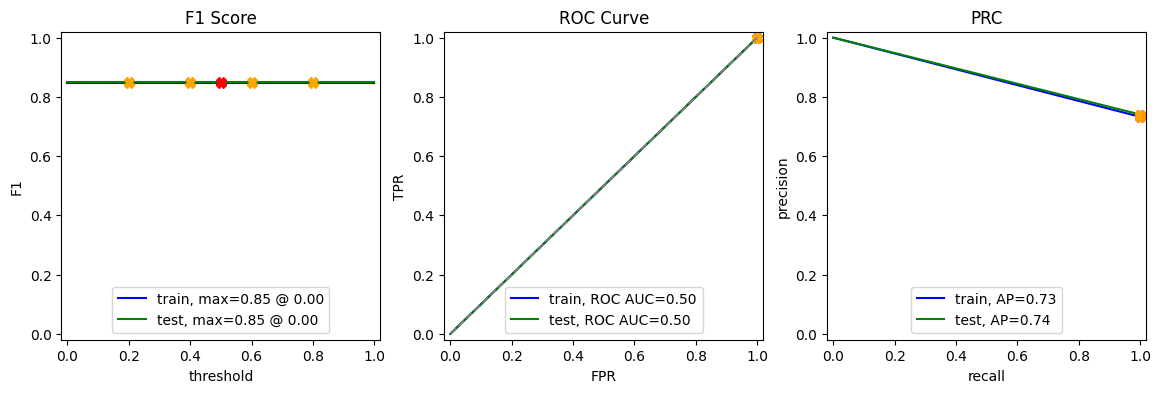

In [66]:
evaluate_model(dummy_clf, features_train, target_train, features_valid, target_valid)

### Logestic Regression Model

In [67]:
lr = LogisticRegression(solver="liblinear",class_weight="balanced", random_state=1234) 
lr.fit(features_ohe_train, target_ohe_train)

LogisticRegression(class_weight='balanced', random_state=1234,
                   solver='liblinear')

          train  test
Accuracy   0.75  0.74
F1         0.81  0.80
APS        0.94  0.93
ROC AUC    0.85  0.83

Confusion Matrix
[[362  95]
 [367 937]]



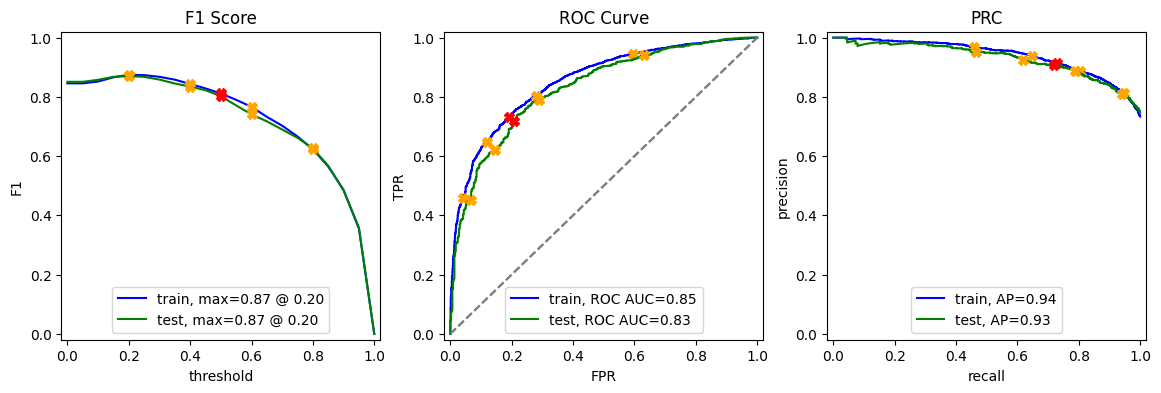

In [68]:
evaluate_model(lr, features_ohe_train, target_ohe_train, features_ohe_valid, target_ohe_valid)

### Random Forest Model

In [69]:
# hyperparameters optimization to find the best settings for Random Forest classifier
%time
param_dist = {
    'n_estimators': randint(50, 300),        
    'max_depth': randint(2, 21),             
    'min_samples_split': randint(2, 11),     
    'min_samples_leaf': randint(1, 5),       
    'max_features': ['auto', 'sqrt']                      
}
rf = RandomForestClassifier(random_state=1234)
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, 
                               n_iter=20, cv=3, verbose=1, random_state=1234, n_jobs=-1)
rf_random.fit(features_lab_train, target_lab_train)
print(f"Best settings: {rf_random.best_params_}")


CPU times: user 1 µs, sys: 0 ns, total: 1 µs
Wall time: 4.77 µs
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best settings: {'max_depth': 18, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 286}


          train  test
Accuracy   0.91  0.81
F1         0.94  0.87
APS        0.99  0.94
ROC AUC    0.98  0.85

Confusion Matrix
[[ 229  228]
 [ 113 1191]]



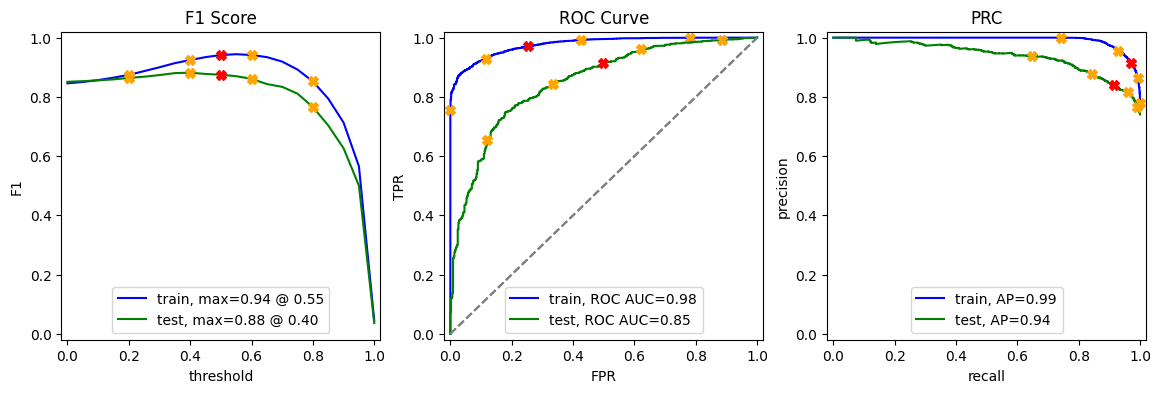

In [70]:
best_model = rf_random.best_estimator_
evaluate_model(best_model, features_lab_train, target_lab_train, features_lab_valid, target_lab_valid)

### LightGBM Model

In [71]:

%time
param_dist2 = {
    'n_estimators': randint(50, 200),       
    'learning_rate':uniform(0.01, 0.5),
    'num_leaves': randint(5, 100),
    'max_depth': randint(10, 200),
    'min_child_samples': randint(1, 18)
}
lg = LGBMClassifier(verbose=1, random_state=1234)
lg_random = RandomizedSearchCV(estimator=lg, param_distributions=param_dist2, scoring='accuracy',
                               n_iter=50, cv=3, verbose=1, random_state=1234, n_jobs=-1)
lg_random.fit(features_lab_train, target_lab_train)
print(f'Best parameter: {lg_random.best_params_}')


CPU times: user 1 µs, sys: 1e+03 ns, total: 2 µs
Wall time: 3.58 µs
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[LightGBM] [Info] Number of positive: 2752, number of negative: 1004
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000575 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 618
[LightGBM] [Info] Number of data points in the train set: 3756, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.732694 -> initscore=1.008336
[LightGBM] [Info] Start training from score 1.008336
[LightGBM] [Info] Number of positive: 2752, number of negative: 1004
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000576 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info]

          train  test
Accuracy   0.85  0.79
F1         0.90  0.86
APS        0.97  0.94
ROC AUC    0.92  0.84

Confusion Matrix
[[ 224  233]
 [ 135 1169]]



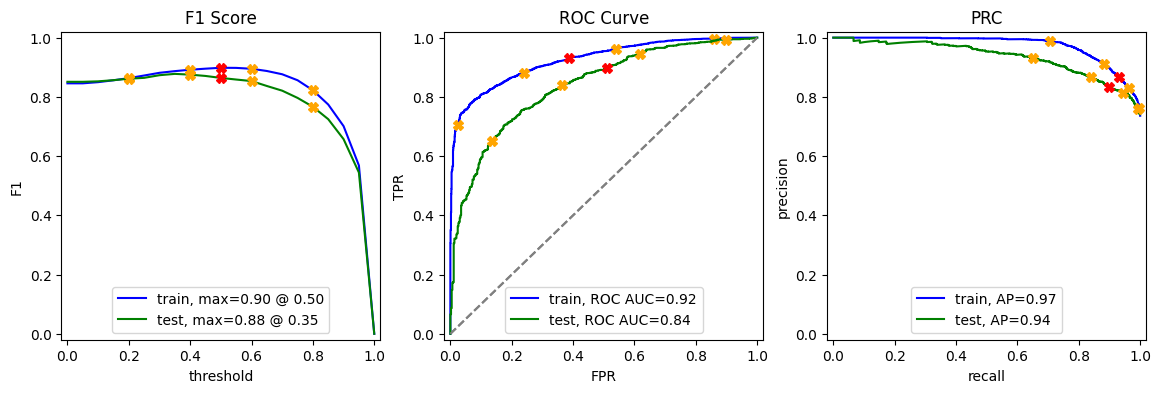

In [72]:
evaluate_model(lg_random, features_lab_train, target_lab_train, features_lab_valid, target_lab_valid)

### CATboost Model

In [73]:
cat_features = ['type', 'paymentmethod', 'internetservice']
cb = CatBoostClassifier(cat_features=cat_features, verbose=False)
cb.fit(features_train, target_train)

          train  test
Accuracy   0.85  0.80
F1         0.90  0.87
APS        0.97  0.94
ROC AUC    0.92  0.84

Confusion Matrix
[[ 243  214]
 [ 141 1163]]



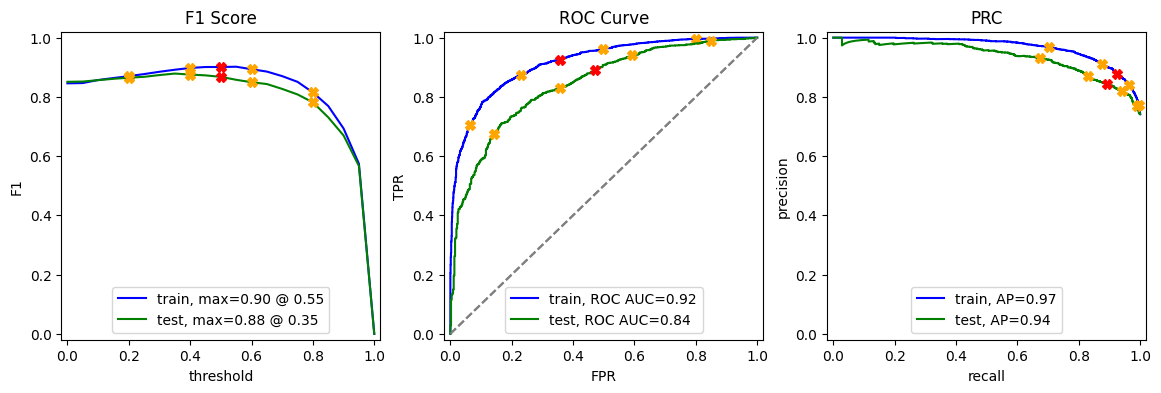

In [74]:
evaluate_model(cb, features_train, target_train, features_valid, target_valid)

### Training Upsampled Data

In [75]:
cb2 = CatBoostClassifier(cat_features=cat_features, verbose=False)
cb2.fit(features_upsampled_train, target_upsampled_train)

          train  test
Accuracy   0.86  0.81
F1         0.87  0.83
APS        0.95  0.93
ROC AUC    0.93  0.89

Confusion Matrix
[[617 146]
 [185 837]]



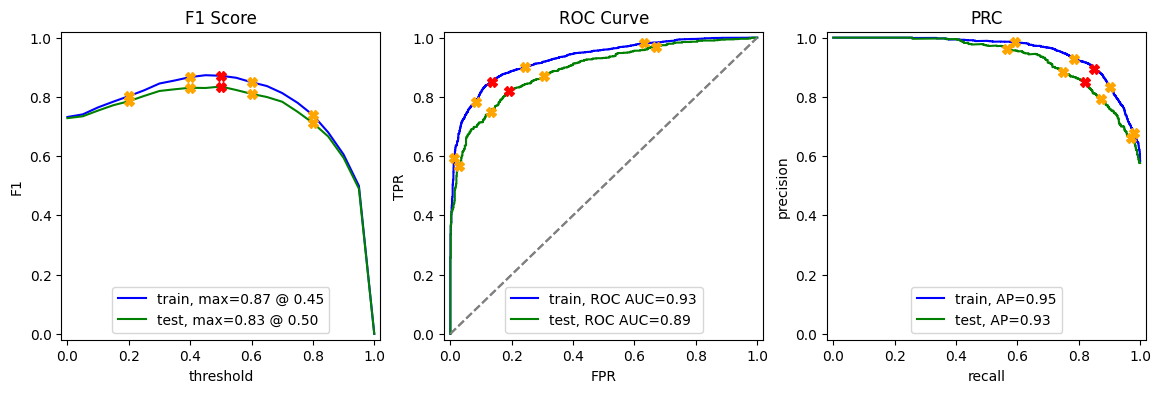

In [76]:
evaluate_model(cb2, features_upsampled_train, target_upsampled_train, features_upsampled_valid, target_upsampled_valid)

In [77]:
features2_upsampled, target2_upsampled = upsample(
    features_lab_train, target_train, 2)
features2_upsampled_train, features2_upsampled_valid, target2_upsampled_train, target2_upsampled_valid = train_test_split(features2_upsampled, target2_upsampled, test_size=0.25, random_state=1234 )

rf2=rf_random.fit(features2_upsampled_train, target2_upsampled_train)
print(f"Best settings: {rf2.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best settings: {'max_depth': 19, 'max_features': 'auto', 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 87}


          train  test
Accuracy   0.96  0.83
F1         0.97  0.85
APS        1.00  0.94
ROC AUC    1.00  0.91

Confusion Matrix
[[628 135]
 [160 862]]



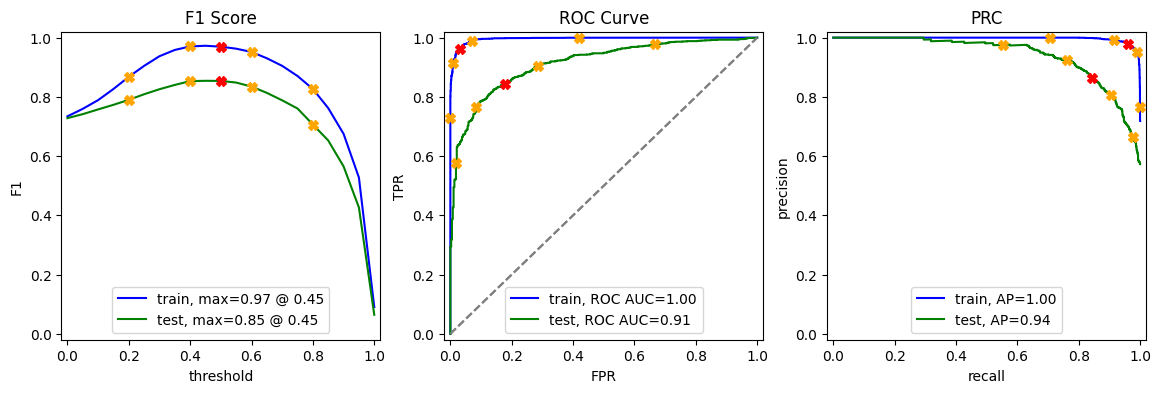

In [78]:
rf_model=rf2.best_estimator_
evaluate_model(rf_model, features2_upsampled_train, target2_upsampled_train, features2_upsampled_valid, target2_upsampled_valid)

# Testing the Model

In [79]:
%time
cb_test = CatBoostClassifier(cat_features=cat_features, verbose=False)
cb_test.fit(features_upsampled_train, target_upsampled_train)

CPU times: user 2 µs, sys: 1 µs, total: 3 µs
Wall time: 4.77 µs


          train  test
Accuracy   0.86  0.80
F1         0.87  0.83
APS        0.95  0.92
ROC AUC    0.93  0.89

Confusion Matrix
[[478 120]
 [160 670]]



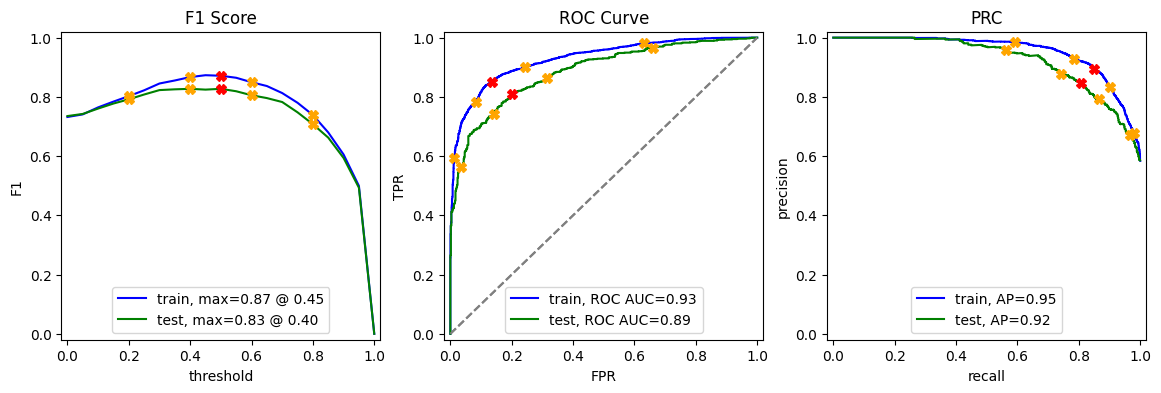

In [80]:
evaluate_model(cb_test, features_upsampled_train, target_upsampled_train, features_upsampled_test, target_upsampled_test)

# Conclusion

In our project we aimed to create a model that will classify when a user is likely to cancel their services. We would determine our model a success based on the ROC-AUC score. A score lower than 0.75 was defined as too low, and an ideal score would be one higher than 0.88. 
First, we preprocessed our data to make all of the metrics usable for building our model. To create a full data set, we made a few key changes. We calculated the number of months a customer had been using the service, encoded our binary features, and counted the number of internet services a customer was utilizing. Doing this, we created a unified data set from our four separate data frames.

Afterwards, we performed exploratory data analysis. Our analysis revealed that customers with higher monthly charges, shorter subscription periods, and month-to-month contracts are significantly more likely to churn. Additionally, customers without dependents showed a higher tendency to leave, suggesting that perceived value and cost sensitivity play an important role in retention. On the other hand, long-term contracts and extended service usage were strongly associated with customer loyalty.

We trained and evaluated multiple models, including Logistic Regression, Random Forest, LightGBM, and CatBoost, while also addressing class imbalance through upsampling techniques. Evaluation metrics such as ROC-AUC, F1 score, and precision-recall curves confirmed that our catboost model is capable of distinguishing between churned and retained customers with good reliability. The catboost model showed slight overfitting, and balancing the data improved it. The ROC-AUC values we got was 0.91.

The results highlight actionable insights. Companies can reduce churn by encouraging customers to commit to longer-term contracts, offering competitive pricing, and improving the early customer experience—especially during the first few months of service.